In [27]:
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, f1_score
import shap
import numpy as np
import pandas as pd
import sys
import os
from pathlib import Path
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
def find_project_root(current_path, marker="requirements.txt"):
    current = Path(current_path).resolve()
    for _ in range(5):
        if (current / marker).exists():
            return current
        current = current.parent
    raise FileNotFoundError(f"Не удалось найти корень проекта (файл {marker})")


PROJECT_ROOT = find_project_root(os.getcwd())
sys.path.append(str(PROJECT_ROOT))
print(f"Корневая директория: {PROJECT_ROOT}")

Корневая директория: D:\Education\Arcticle\02_dtp_project_JAER


# Данные

In [3]:
df = pd.read_parquet(rf"{PROJECT_ROOT}\data\processed\dtp_msk.parquet")
df

,light_cat,scheme,category,year,month_sin,month_cos,hour_sin,hour_cos,is_weekend,near_residential,...,ppl_drv_novice,viol_priority,viol_pedestrian,viol_speed,viol_drunk,viol_safety,viol_rights,viol_runaway,viol_admin,target
0,day,200,столкновение,2023,1.224647e-16,-1.000000,-0.965926,-2.588190e-01,0,1,...,1,0,1,0,0,0,0,0,0,0
1,day,300,столкновение,2015,8.660254e-01,-0.500000,-1.000000,-1.836970e-16,0,1,...,0,1,0,0,0,0,1,0,1,0
2,day,500,столкновение,2015,8.660254e-01,0.500000,-0.866025,-5.000000e-01,0,0,...,0,1,0,0,0,0,0,0,0,1
3,day,820,наезд_на_пешехода,2015,8.660254e-01,0.500000,0.707107,-7.071068e-01,0,1,...,0,0,1,0,0,0,0,0,0,0
4,day,300,столкновение,2015,8.660254e-01,0.500000,-1.000000,-1.836970e-16,0,1,...,0,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91744,day,950,опрокидывание,2025,1.224647e-16,-1.000000,-1.000000,-1.836970e-16,0,1,...,0,0,0,1,0,0,0,0,0,0
91745,day,070,столкновение,2025,1.224647e-16,-1.000000,0.866025,-5.000000e-01,1,0,...,0,0,0,1,0,0,0,0,0,1
91746,day,300,столкновение,2025,5.000000e-01,-0.866025,0.866025,-5.000000e-01,1,0,...,0,1,0,0,0,0,0,0,1,2
91747,night_lit,200,столкновение,2025,5.000000e-01,-0.866025,-0.258819,9.659258e-01,1,1,...,1,1,0,0,1,0,0,0,0,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91749 entries, 0 to 91748
Data columns (total 89 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   light_cat                       91749 non-null  object 
 1   scheme                          91749 non-null  object 
 2   category                        91749 non-null  object 
 3   year                            91749 non-null  int32  
 4   month_sin                       91749 non-null  float64
 5   month_cos                       91749 non-null  float64
 6   hour_sin                        91749 non-null  float64
 7   hour_cos                        91749 non-null  float64
 8   is_weekend                      91749 non-null  int32  
 9   near_residential                91749 non-null  int64  
 10  near_pedestrian_infrastructure  91749 non-null  int64  
 11  near_road_junctions             91749 non-null  int64  
 12  near_education                  

In [5]:
print(df["target"].value_counts())

target
0    66704
1    20945
2     4100
Name: count, dtype: int64


In [6]:
nans = df.isna().sum()
nans = nans[nans > 0]
if not nans.empty:
    print("НАЙДЕНЫ ПРОПУСКИ (NaN):")
    print(nans)
else:
    print("Пропусков нет. Датасет плотный.")

Пропусков нет. Датасет плотный.


In [7]:
print("ТИПЫ ДАННЫХ:")
print(df.dtypes.value_counts())

ТИПЫ ДАННЫХ:
int64      71
float64    11
object      4
int32       3
Name: count, dtype: int64


In [8]:
print(df["region_id"].value_counts()[:10])

region_id
москва__выхиножулебино      1399
москва__люблино             1356
москва__пресненский         1350
москва__спецтрассы          1347
москва__южное_бутово        1323
москва__марьино             1256
москва__даниловский         1247
москва__митино              1236
москва__строгино            1204
москва__хорошевомневники    1196
Name: count, dtype: int64


In [15]:
df['target'] = (df['target'] > 0).astype(int)

In [16]:
print(df["target"].value_counts())

target
0    66704
1    25045
Name: count, dtype: int64


In [17]:
X_cat = df.drop(columns=["target"])
y = df["target"]

# Указываем категориальные фичи для CatBoost
cat_features = ["light_cat", "scheme", "category", "region_id"]

In [18]:
X_logit_raw = df.drop(columns=["target", "region_id", "lat", "long"])

X_logit = pd.get_dummies(
    X_logit_raw, columns=["light_cat", "scheme", "category"], drop_first=True
)

## Разделение на трейн и тест

In [19]:
X_cat_train, X_cat_test, y_train, y_test = train_test_split(
    X_cat, y, test_size=0.2, random_state=42, stratify=y
)

X_logit_train, X_logit_test, _, _ = train_test_split(
    X_logit, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Размер обучающей выборки: {X_cat_train.shape[0]}")
print(f"Размер тестовой выборки: {X_cat_test.shape[0]}")
print(f"Признаков для CatBoost: {X_cat_train.shape[1]}")
print(f"Признаков для Logit: {X_logit_train.shape[1]}")  # Их станет больше из-за OHE

Размер обучающей выборки: 73399
Размер тестовой выборки: 18350
Признаков для CatBoost: 88
Признаков для Logit: 154


# Модели

## Катбуст

In [20]:
# ==========================================
# 1. ОБУЧЕНИЕ CATBOOST
# ==========================================
print("--- 1. Обучение CatBoost ---")
cb_model = CatBoostClassifier(
    iterations=700, random_seed=42, auto_class_weights="Balanced", verbose=100
)
cb_model.fit(X_cat_train, y_train, cat_features=cat_features)

cb_probs = cb_model.predict_proba(X_cat_test)[:, 1]
cb_preds = cb_model.predict(X_cat_test)

cb_roc = roc_auc_score(y_test, cb_probs)
cb_f1 = f1_score(y_test, cb_preds)

--- 1. Обучение CatBoost ---
Learning rate set to 0.08946
0:	learn: 0.6827289	total: 116ms	remaining: 1m 21s
100:	learn: 0.5852417	total: 9.51s	remaining: 56.4s
200:	learn: 0.5639487	total: 18.7s	remaining: 46.5s
300:	learn: 0.5507172	total: 27.8s	remaining: 36.9s
400:	learn: 0.5404181	total: 37.1s	remaining: 27.7s
500:	learn: 0.5307345	total: 46.4s	remaining: 18.4s
600:	learn: 0.5223249	total: 55.6s	remaining: 9.16s
699:	learn: 0.5143111	total: 1m 4s	remaining: 0us


## SHAP

--- 2. Расчет SHAP ---
ТОП-15 ПРИЗНАКОВ ПО SHAP:
1. region_id
2. year
3. scheme
4. ppl_ped_count
5. lat
6. category
7. viol_runaway
8. long
9. vh_count_car
10. vh_count_moto
11. near_administrative
12. light_cat
13. ppl_count
14. hour_cos
15. near_residential


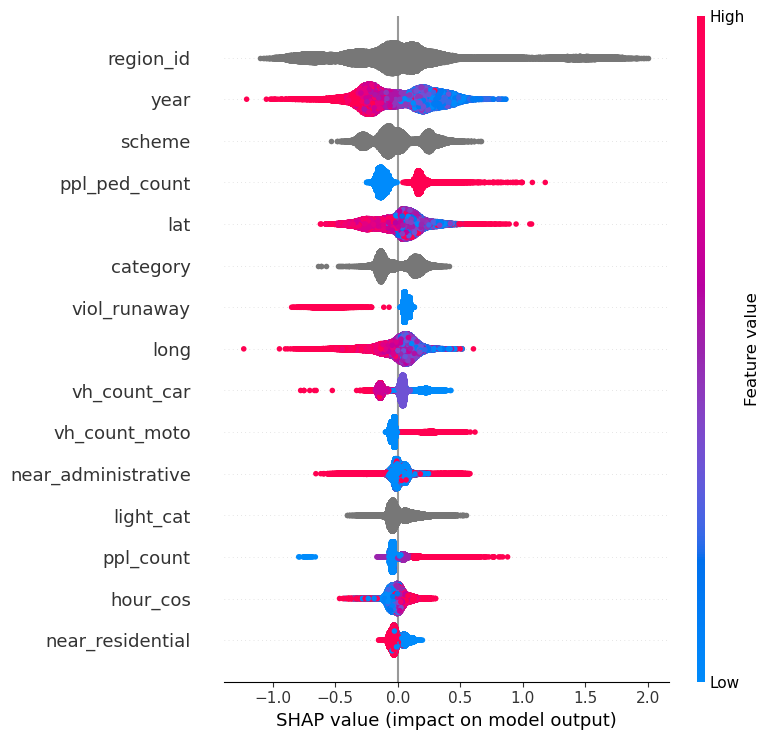

In [29]:
# ==========================================
# 2. ИЗВЛЕЧЕНИЕ SHAP И ТОП-15 ПРИЗНАКОВ
# ==========================================
print("--- 2. Расчет SHAP ---")
explainer = shap.TreeExplainer(cb_model)
# Считаем SHAP. Для скорости можно взять выборку (например, 20000 строк), но 73k CatBoost посчитает быстро
shap_values = explainer.shap_values(X_cat_train)

# Вычисляем средний модуль SHAP для каждого признака (глобальная важность)
shap_sum = np.abs(shap_values).mean(axis=0)
importance_df = pd.DataFrame(
    {"feature_name": X_cat_train.columns, "shap_importance": shap_sum}
).sort_values("shap_importance", ascending=False)

top_15_features = importance_df.head(15)["feature_name"].tolist()
print("ТОП-15 ПРИЗНАКОВ ПО SHAP:")
for i, f in enumerate(top_15_features, 1):
    print(f"{i}. {f}")

# Вывод графика SHAP (сохрани его, он пойдет в статью!)
shap.summary_plot(shap_values, X_cat_train, max_display=15, show=False)
# plt.savefig('shap_summary.png', bbox_inches='tight') # Раскомментируй, чтобы сохранить

## "ГРЯЗНАЯ" ЭКОНОМЕТРИКА

In [22]:
# ==========================================
# 3. "ГРЯЗНАЯ" ЭКОНОМЕТРИКА (ВСЕ ПРИЗНАКИ)
# ==========================================
print("--- 3. Обучение Logit (Все признаки) ---")
# Линейные модели ТРЕБУЮТ масштабирования (иначе не сойдутся)
scaler_base = StandardScaler()
X_logit_train_scaled = scaler_base.fit_transform(X_logit_train)
X_logit_test_scaled = scaler_base.transform(X_logit_test)

logit_base = LogisticRegression(max_iter=2000, random_state=42, class_weight="balanced")
logit_base.fit(X_logit_train_scaled, y_train)

lb_probs = logit_base.predict_proba(X_logit_test_scaled)[:, 1]
lb_preds = logit_base.predict(X_logit_test_scaled)

lb_roc = roc_auc_score(y_test, lb_probs)
lb_f1 = f1_score(y_test, lb_preds)

--- 3. Обучение Logit (Все признаки) ---


## "ЧИСТАЯ" ЭКОНОМЕТРИКА

In [23]:
# ==========================================
# 4. "ЧИСТАЯ" ЭКОНОМЕТРИКА (ТОЛЬКО ТОП-15 SHAP)
# ==========================================
print("--- 4. Обучение Logit (Топ-15 SHAP) ---")
# Находим нужные колонки. Так как в Logit категории разбиты через OHE (напр. category_наезд),
# мы ищем все колонки, которые начинаются с названий наших топ-15 признаков.
top_logit_cols = [
    c
    for c in X_logit_train.columns
    if any(c == f or c.startswith(f + "_") for f in top_15_features)
]

X_logit_train_top = X_logit_train[top_logit_cols]
X_logit_test_top = X_logit_test[top_logit_cols]

scaler_top = StandardScaler()
X_logit_train_top_scaled = scaler_top.fit_transform(X_logit_train_top)
X_logit_test_top_scaled = scaler_top.transform(X_logit_test_top)

logit_top = LogisticRegression(max_iter=2000, random_state=42, class_weight="balanced")
logit_top.fit(X_logit_train_top_scaled, y_train)

lt_probs = logit_top.predict_proba(X_logit_test_top_scaled)[:, 1]
lt_preds = logit_top.predict(X_logit_test_top_scaled)

lt_roc = roc_auc_score(y_test, lt_probs)
lt_f1 = f1_score(y_test, lt_preds)

--- 4. Обучение Logit (Топ-15 SHAP) ---


## Сравнение

In [24]:
# ==========================================
# 5. ИТОГОВОЕ СРАВНЕНИЕ
# ==========================================
print("==========================================")
print("ФИНАЛЬНЫЕ МЕТРИКИ (ТЕСТОВАЯ ВЫБОРКА):")
print(f"1. CatBoost (Все признаки):     ROC-AUC = {cb_roc:.4f} | F1 = {cb_f1:.4f}")
print(f"2. Logit (Все признаки):        ROC-AUC = {lb_roc:.4f} | F1 = {lb_f1:.4f}")
print(f"3. Logit (Топ-15 SHAP фильтр):  ROC-AUC = {lt_roc:.4f} | F1 = {lt_f1:.4f}")
print("==========================================")

ФИНАЛЬНЫЕ МЕТРИКИ (ТЕСТОВАЯ ВЫБОРКА):
1. CatBoost (Все признаки):     ROC-AUC = 0.7726 | F1 = 0.5585
2. Logit (Все признаки):        ROC-AUC = 0.6937 | F1 = 0.4931
3. Logit (Топ-15 SHAP фильтр):  ROC-AUC = 0.6755 | F1 = 0.4780


## Анализ

### Матрица корреляций

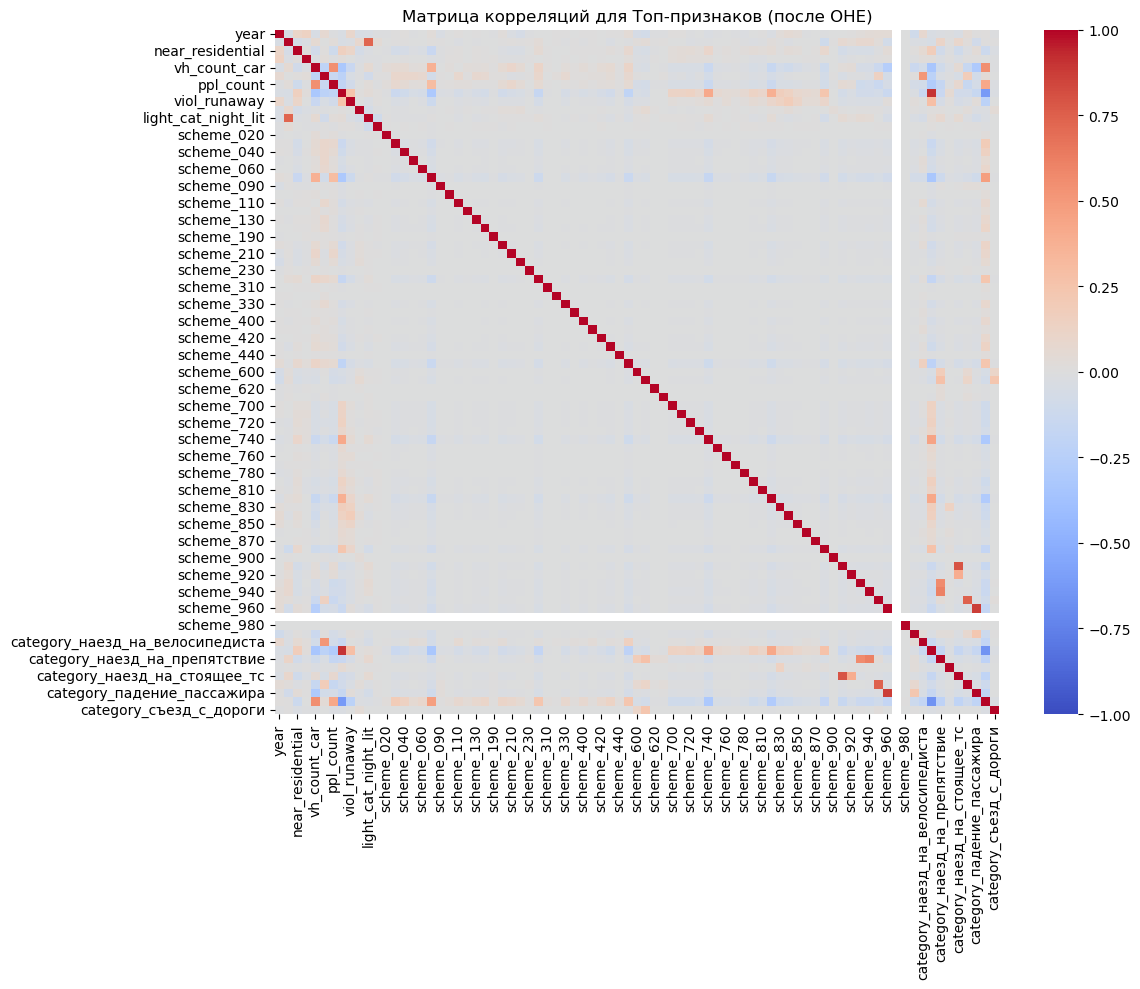

In [25]:
# 1. СТРОИМ МАТРИЦУ КОРРЕЛЯЦИЙ (HEATMAP)
plt.figure(figsize=(12, 10))
# Считаем корреляцию Пирсона. Берем X_logit_train_top (там уже сделан OHE для категорий)
corr_matrix = X_logit_train_top.corr()

# Рисуем тепловую карту (сохрани этот график для статьи!)
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Матрица корреляций для Топ-признаков (после OHE)')
plt.tight_layout()
plt.show()

### VIF

In [ ]:
print("--- Расчет VIF (Исправленный) ---")

# 1. Принудительно конвертируем всё в числа (решает ошибку TypeError)
X_vif_clean = X_logit_train_top.astype(float)

# 2. Удаляем константные признаки (те самые "серые полосы" на графике, где дисперсия = 0)
X_vif_clean = X_vif_clean.loc[:, X_vif_clean.std() > 0]

# 3. Добавляем константу и считаем VIF
X_vif = add_constant(X_vif_clean)

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns

# Считаем VIF (оборачиваем в try-except на случай жесткой коллинеарности)
vifs = []
for i in range(X_vif.shape[1]):
    try:
        vifs.append(variance_inflation_factor(X_vif.values, i))
    except:
        vifs.append(np.inf) # Если деление на ноль, значит VIF бесконечный

vif_data["VIF"] = vifs

# Выводим Топ-15 признаков с самым высоким VIF (исключая константу)
vif_data = vif_data[vif_data['Feature'] != 'const'].sort_values(by="VIF", ascending=False)

print(vif_data.head(15))

--- Расчет VIF (Исправленный) ---
                            Feature         VIF
79            category_столкновение  176.724274
73       category_наезд_на_пешехода  162.577233
74    category_наезд_на_препятствие   40.398104
18                       scheme_070   40.070104
49                       scheme_740   35.219041
76     category_наезд_на_стоящее_тс   33.983908
78       category_падение_пассажира   32.006973
56                       scheme_820   31.351340
72  category_наезд_на_велосипедиста   27.052117
40                       scheme_500   20.492339
69                       scheme_960   16.600144
30                       scheme_300   14.887869
62                       scheme_880   13.616314
77           category_опрокидывание   12.671271
64                       scheme_910   12.299498


## Ручная очистка

In [39]:
# 1. Задаем наш "Умный список" (Очищенный от мультиколлинеарности Топ SHAP)
smart_features = [
    'year', 'viol_runaway', 'vh_count_truck', 'near_administrative', 
    'light_cat', 'hour_cos', 'near_residential', 'ppl_drv_female', 
    'viol_drunk', 'weather_overcast', 'month_sin', 'vh_mean_age', 'ppl_drv_exp_mean'
]

In [40]:
smart_features = [
    'year', 'viol_runaway', 'vh_count_truck', 'near_administrative', 
    'light_cat', 'hour_cos', 'near_residential', 'ppl_drv_female', 
    'viol_drunk', 'weather_overcast', 'month_sin', 'vh_mean_age', 
    'ppl_drv_exp_mean', 
    # --- НОВЫЕ БЕЗОПАСНЫЕ ПРИЗНАКИ ---
    'is_weekend',             # Выходные (часто ездят быстрее и пьянее)
    'viol_speed',             # Превышение скорости (очевидный драйвер тяжести)
    'vh_heavy_light_conflict',# Столкновение фуры и легковушки
    'road_ice',               # Гололед
    'road_snow',              # Снег на дороге
    'weather_snow',           # Снегопад
    'vh_is_solo'              # Одиночное ДТП (влетел в столб)
]

In [41]:
# Находим соответствующие колонки в X_logit_train (учитывая OHE для light_cat)
smart_cols = [c for c in X_logit_train.columns if any(c == f or c.startswith(f + '_') for f in smart_features)]

X_train_smart = X_logit_train[smart_cols]
X_test_smart = X_logit_test[smart_cols]

In [42]:
# 2. Проверяем VIF (Должен быть < 5)
X_vif_clean = X_train_smart.astype(float)
X_vif_clean = X_vif_clean.loc[:, X_vif_clean.std() > 0] # Убираем константы
X_vif = add_constant(X_vif_clean)

print("--- VIF для Умного фильтра ---")
vifs = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
vif_df = pd.DataFrame({'Feature': X_vif.columns, 'VIF': vifs})
print(vif_df[vif_df['Feature'] != 'const'].sort_values('VIF', ascending=False).head(5))

--- VIF для Умного фильтра ---
                    Feature       VIF
21      light_cat_night_lit  2.495828
3                  hour_cos  2.416313
12  vh_heavy_light_conflict  1.728554
14           vh_count_truck  1.667106
8              weather_snow  1.414048


In [43]:
# 3. Обучаем Логит
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_smart)
X_test_scaled = scaler.transform(X_test_smart)

logit_smart = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
logit_smart.fit(X_train_scaled, y_train)

roc_smart = roc_auc_score(y_test, logit_smart.predict_proba(X_test_scaled)[:, 1])
print(f"ROC-AUC (Smart Logit): {roc_smart:.4f}")

ROC-AUC (Smart Logit): 0.6591


In [37]:
# 4. ВЫВОДИМ ИНТЕРПРЕТАЦИЮ (Odds Ratios)
print("--- ИНТЕРПРЕТАЦИЯ (Как факторы влияют на тяжесть) ---")
# Возвращаем коэффициенты к исходному масштабу для понимания
coefs = logit_smart.coef_[0] / scaler.scale_
odds_ratios = np.exp(coefs)

interpretation = pd.DataFrame({
    'Feature': smart_cols,
    'Odds_Ratio': odds_ratios
}).sort_values('Odds_Ratio', ascending=False)

print(interpretation)

--- ИНТЕРПРЕТАЦИЯ (Как факторы влияют на тяжесть) ---
                 Feature  Odds_Ratio
12  light_cat_night_dark    3.802910
10            viol_drunk    1.696617
7         vh_count_truck    1.224440
13   light_cat_night_lit    1.121336
2               hour_cos    1.116425
6            vh_mean_age    1.015746
9       ppl_drv_exp_mean    1.003754
14    light_cat_twilight    0.981200
1              month_sin    0.948725
0                   year    0.904185
4    near_administrative    0.899017
5       weather_overcast    0.804208
3       near_residential    0.765451
8         ppl_drv_female    0.744313
11          viol_runaway    0.578193
